In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("11_adspend_vs_website_visits.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
  ad_spend_usd marketing_spend_usd competitor_price_usd season_index  \
0        207.0               72.97                54.28            2   
1         71.0              496.65                 24.5            2   
2        821.0              492.13                39.12            2   
3        400.0              423.65                30.72            4   
4        618.0              151.45                35.25            3   

  website_visits  
0            764  
1            215  
2           3377  
3           1900  
4           2006  

Shape of dataset:
(311, 5)

Columns:
Index(['ad_spend_usd', 'marketing_spend_usd', 'competitor_price_usd',
       'season_index', 'website_visits'],
      dtype='object')

Data types:
ad_spend_usd            object
marketing_spend_usd     object
competitor_price_usd    object
season_index            object
website_visits          object
dtype: object

Missing values:
ad_spend_usd             6
marketing_spend_usd     14
competitor_pri

In [2]:
# Convert required columns to numeric

df["ad_spend_usd"] = pd.to_numeric(
    df["ad_spend_usd"], errors="coerce"
)

df["website_visits"] = pd.to_numeric(
    df["website_visits"], errors="coerce"
)

# Remove missing values

df = df.dropna(
    subset=["ad_spend_usd", "website_visits"]
)

# Create binary target using median website visits

median_visits = df["website_visits"].median()

df["website_visits_class"] = (
    df["website_visits"] >= median_visits
).astype(int)

print("Median Website Visits:", median_visits)

print("\nBinary Target:")
print(df["website_visits_class"].value_counts())

print("\nDataset:")
print(df[[
    "ad_spend_usd",
    "website_visits",
    "website_visits_class"
]].head())

Median Website Visits: 1757.0

Binary Target:
website_visits_class
1    148
0    147
Name: count, dtype: int64

Dataset:
   ad_spend_usd  website_visits  website_visits_class
0         207.0           764.0                     0
1          71.0           215.0                     0
2         821.0          3377.0                     1
3         400.0          1900.0                     1
4         618.0          2006.0                     1


In [3]:
# Input feature

X = df[["ad_spend_usd"]]

# Binary target variable

y = df["website_visits_class"]

print("Input Feature:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("website_visits_class")

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

Input Feature:
['ad_spend_usd']

Target Variable:
website_visits_class

Training data shape:
(236, 1)

Testing data shape:
(59, 1)


In [4]:
# Build Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

# Generate predictions

y_pred = model.predict(X_test)

print("Raw continuous predictions:")
print(y_pred[:10])

print("\nModel Coefficient:")
print(model.coef_)

print("\nModel Intercept:")
print(model.intercept_)

Raw continuous predictions:
[ 0.57808662  1.04871267  0.34981889  1.14171064  0.31036521  1.04025831
  0.2469575  -0.17012427  1.20370928  0.14691424]

Model Coefficient:
[0.00140906]

Model Intercept:
-0.19126017176502502


In [5]:
# Classification threshold

threshold = 0.5

# Convert continuous predictions into class labels

y_pred_class = (
    y_pred >= threshold
).astype(int)

# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred_class
)

print("Classification Threshold:", threshold)

print("\nPredicted Classes:")
print(y_pred_class[:10])

print("\nActual Classes:")
print(y_test.values[:10])

print("\nAccuracy:")
print(accuracy)

Classification Threshold: 0.5

Predicted Classes:
[1 1 0 1 0 1 0 0 1 0]

Actual Classes:
[1 1 1 1 0 1 0 0 1 0]

Accuracy:
0.8983050847457628


C:\Users\chait\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


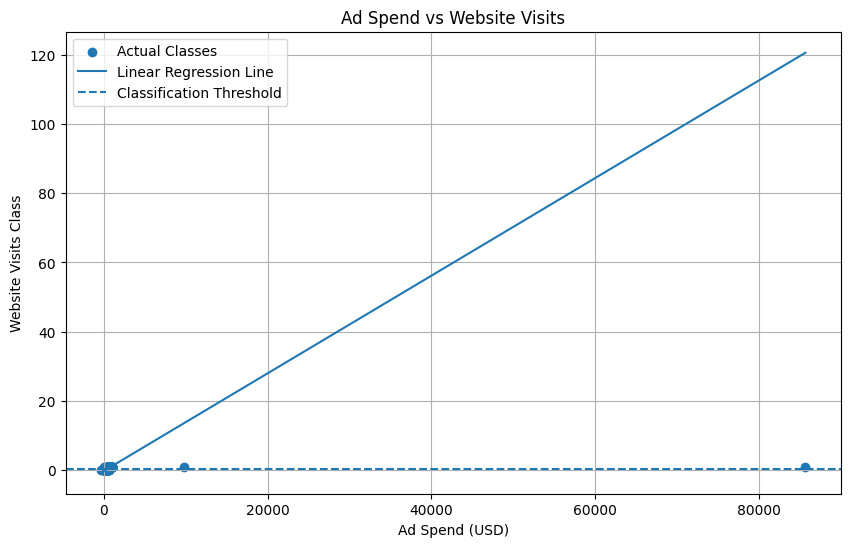

In [6]:
# Create values for regression line

X_line = np.linspace(
    X["ad_spend_usd"].min(),
    X["ad_spend_usd"].max(),
    100
).reshape(-1, 1)

y_line = model.predict(X_line)

plt.figure(figsize=(10, 6))

# Actual observations

plt.scatter(
    X["ad_spend_usd"],
    y,
    label="Actual Classes"
)

# Linear Regression line

plt.plot(
    X_line,
    y_line,
    label="Linear Regression Line"
)

# Classification threshold

plt.axhline(
    y=threshold,
    linestyle="--",
    label="Classification Threshold"
)

plt.xlabel("Ad Spend (USD)")
plt.ylabel("Website Visits Class")
plt.title("Ad Spend vs Website Visits")

plt.legend()
plt.grid(True)

plt.show()

In [7]:
# Change classification threshold

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Threshold Comparison:\n")

for threshold in thresholds:

    y_pred_class = (
        y_pred >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_class
    )

    print(
        "Threshold:",
        threshold,
        "Accuracy:",
        accuracy
    )

Threshold Comparison:

Threshold: 0.3 Accuracy: 0.847457627118644
Threshold: 0.4 Accuracy: 0.8813559322033898
Threshold: 0.5 Accuracy: 0.8983050847457628
Threshold: 0.6 Accuracy: 0.8983050847457628
Threshold: 0.7 Accuracy: 0.8135593220338984


In [8]:
# New observation

new_observation = pd.DataFrame({
    "ad_spend_usd": [500]
})

# Raw continuous prediction

raw_prediction = model.predict(
    new_observation
)[0]

# Classification threshold

threshold = 0.5

# Final class

final_class = int(
    raw_prediction >= threshold
)

print("New Observation:")
print(new_observation)

print("\nRaw Prediction:")
print(raw_prediction)

print("\nClassification Threshold:")
print(threshold)

print("\nFinal Class:")
print(final_class)

if final_class == 1:
    print("Interpretation: High Website Visits")
else:
    print("Interpretation: Low Website Visits")

New Observation:
   ad_spend_usd
0           500

Raw Prediction:
0.5132698540596099

Classification Threshold:
0.5

Final Class:
1
Interpretation: High Website Visits


In [ ]:
print("Limitations of Linear Regression for Binary Classification:")
print()
print("1. Linear Regression produces continuous output values.")
print("2. Predictions can be less than 0 or greater than 1.")
print("3. A classification threshold must be manually selected.")
print("4. The predicted values are not probabilities.")
print("5. Accuracy can change when the classification threshold changes.")
print()
print("Why Logistic Regression is preferred:")
print("Logistic Regression is specifically designed for binary classification.")
print("It produces probability values between 0 and 1.")
print("A classification threshold can then be used to assign class labels.")